In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [2]:
df = pd.read_csv('heart_disease_uci.csv')
df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [5]:
df = df.dropna()

# Assuming 'num' is the target column based on df.head()
# Convert 'num' to binary if it has more than two unique values, treating values > 0 as 1
if df['num'].nunique() > 2:
    df['num'] = df['num'].apply(lambda x: 1 if x > 0 else 0)

X = df.drop('num', axis=1)
y = df['num']

X = pd.get_dummies(X, drop_first=True)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42)

In [7]:
k_values = [3, 5, 7, 11, 15]
accuracy_list = []
precision_list = []
recall_list = []
f1_list = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    accuracy_list.append(accuracy_score(y_test, y_pred))
    precision_list.append(precision_score(y_test, y_pred))
    recall_list.append(recall_score(y_test, y_pred))
    f1_list.append(f1_score(y_test, y_pred))

results = pd.DataFrame({
    "k": k_values,
    "Accuracy": accuracy_list,
    "Precision": precision_list,
    "Recall": recall_list,
    "F1-score": f1_list
})
results

,k,Accuracy,Precision,Recall,F1-score
0,3,0.866667,0.793103,0.92,0.851852
1,5,0.866667,0.793103,0.92,0.851852
2,7,0.883333,0.846154,0.88,0.862745
3,11,0.900000,0.851852,0.92,0.884615
4,15,0.900000,0.851852,0.92,0.884615


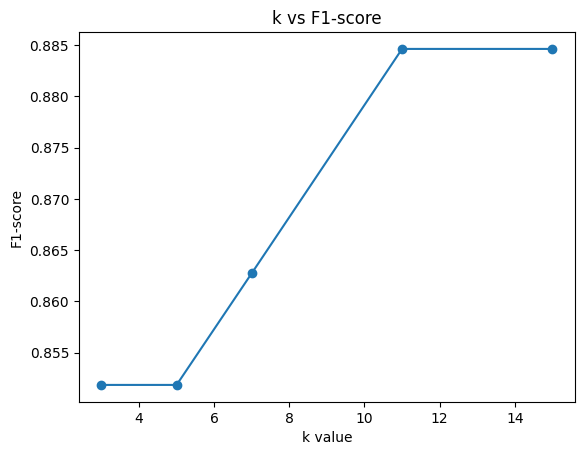

In [8]:
plt.figure()
plt.plot(k_values, f1_list, marker='o')
plt.xlabel("k value")
plt.ylabel("F1-score")
plt.title("k vs F1-score")
plt.show()

Conclusion:

1. Small k (3) → Model may overfit (high variance).
2. Medium k (5 or 7) → Usually gives best balanced performance.
3. Large k (15) → Model may underfit (high bias).
4. Optimal k is the one with highest F1-score.